# RetentionIQ: Exploratory Data Analysis

This notebook explores a synthetic SaaS customer churn dataset created for the RetentionIQ project. The dataset represents customers of a subscription-based software product and includes information about their `plan type`, `product usage`, `onboarding status`, `support activity`, `billing issues`, and `churn status`.

In this project, **churn** means a customer has stopped using or cancelled their subscription to the product.

The goal of this analysis is to understand the main behaviours and customer characteristics associated with churn before building a machine learning model. This will help identify useful patterns, generate product insights, and guide the design of a churn prediction and retention dashboard.

Key questions explored in this notebook include:

- What is the overall churn rate?
- Which subscription plans have higher churn?
- Do inactive customers churn more?
- Does feature usage affect retention?
- Are billing issues linked to higher churn?
- Does completing training or onboarding reduce churn?
- Do support tickets indicate churn risk?

### Step 1: Load the dataset

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('../data/saas_churn_data.csv')
df.head() 


,customer_id,plan_type,country,company_size,days_active_last_30,last_login_days_ago,features_used,team_members_added,support_tickets,billing_issues,subscription_age_months,emails_opened_last_30,training_completed,monthly_fee,signup_date,churned
0,CUST-1,Starter,Canada,Small,20,28,1,20,1,0,31,7,0,29,2025-07-26,0
1,CUST-2,Enterprise,Nigeria,Medium,16,5,4,15,1,0,19,1,1,249,2025-03-24,0
2,CUST-3,Pro,Canada,Small,14,21,5,14,3,0,24,3,0,79,2024-10-08,0
3,CUST-4,Starter,US,Large,5,2,9,4,2,0,9,9,1,29,2025-11-05,0
4,CUST-5,Free,US,Small,15,9,7,5,3,0,23,12,1,0,2024-02-26,0


### Step 2: Inspect the dataset

In [2]:
#checking for the general info about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   customer_id              2000 non-null   str  
 1   plan_type                2000 non-null   str  
 2   country                  2000 non-null   str  
 3   company_size             2000 non-null   str  
 4   days_active_last_30      2000 non-null   int64
 5   last_login_days_ago      2000 non-null   int64
 6   features_used            2000 non-null   int64
 7   team_members_added       2000 non-null   int64
 8   support_tickets          2000 non-null   int64
 9   billing_issues           2000 non-null   int64
 10  subscription_age_months  2000 non-null   int64
 11  emails_opened_last_30    2000 non-null   int64
 12  training_completed       2000 non-null   int64
 13  monthly_fee              2000 non-null   int64
 14  signup_date              2000 non-null   str  
 15  churned        

In [3]:
#the dataset has 2000rows and 16columns 
df.shape

(2000, 16)

In [4]:
#checking for missing values
df.isnull().sum()

customer_id                0
plan_type                  0
country                    0
company_size               0
days_active_last_30        0
last_login_days_ago        0
features_used              0
team_members_added         0
support_tickets            0
billing_issues             0
subscription_age_months    0
emails_opened_last_30      0
training_completed         0
monthly_fee                0
signup_date                0
churned                    0
dtype: int64

In [5]:
#checking for duplicates
df.duplicated().sum()

np.int64(0)

In [6]:
#Step 3: Overall churn rate

churned = df['churned'].mean() * 100
overall_churn_rate = round(churned, 2)
print(f"Overall Churn Rate: {overall_churn_rate}%")

Overall Churn Rate: 27.95%


The overall churn rate is approximately 28%, meaning about 1 in 4 customers in the dataset churned.

### Step 4: Analyse churn by plan
Question:
- Which subscription plan has the highest churn?

In [7]:
df.groupby("plan_type")["churned"].mean() * 100

churn_by_plan = df.groupby("plan_type")["churned"].mean().sort_values(ascending=False) * 100
churn_by_plan


plan_type
Free          31.499051
Pro           30.322581
Starter       26.067073
Enterprise    17.258883
Name: churned, dtype: float64

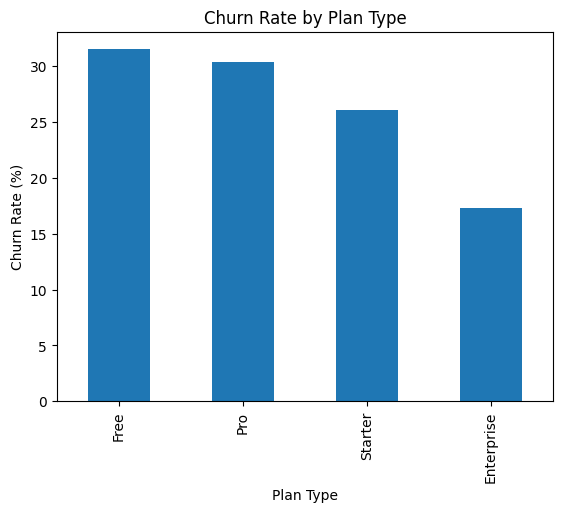

In [8]:
churn_by_plan.plot(kind="bar")
plt.title("Churn Rate by Plan Type")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Plan Type")
plt.show()


### Churn by Plan Type

Free users have the highest churn rate at around 31.5%, while Enterprise users have the lowest churn rate at around 17.3%. This suggests that higher-commitment customers are less likely to churn.

Interestingly, Pro users have a slightly higher churn rate than Starter users. This may suggest that some Pro customers are not getting enough value from the product despite paying for a higher plan. This is worth exploring further by looking at feature usage, activity level, and support tickets within each plan.

### Step 5: Analyse churn by activity

Question:

- Do inactive users churn more?


In [9]:
# First create activity groups:
df["activity_level"] = pd.cut(
    df["days_active_last_30"],
    bins=[-1, 4, 14, 30],
    labels=["Low activity", "Medium activity", "High activity"]
)

# Then analyse churn by activity level:

churn_by_activity = df.groupby("activity_level")["churned"].mean() * 100
churn_by_activity


activity_level
Low activity       47.962382
Medium activity    28.460342
High activity      21.483622
Name: churned, dtype: float64

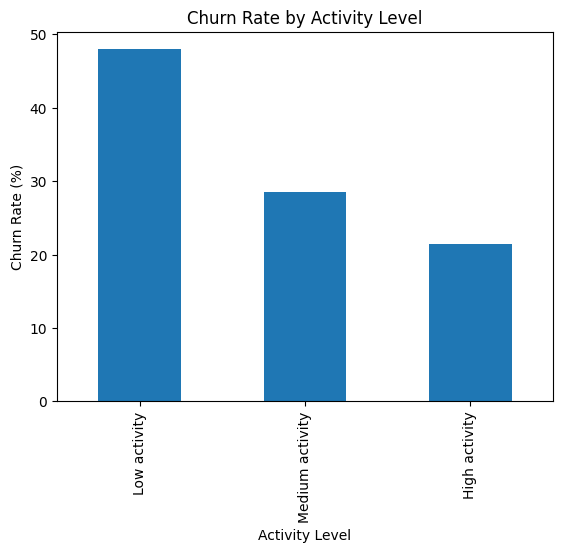

In [10]:
churn_by_activity.plot(kind="bar")
plt.title("Churn Rate by Activity Level")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Activity Level")
plt.show()


 ### Churn by Activity Level

Customers with low activity have the highest churn rate at around 48%, compared to 28.5% for medium-activity customers and 21.5% for high-activity customers.

This suggests that product usage is strongly linked to retention. Customers who are not actively using the product are much more likely to churn, while customers who use the product more frequently are more likely to stay.

From a product perspective, this means the business should monitor customer activity closely and trigger reactivation campaigns when usage starts to drop.

### Step 6: Analyse churn by feature usage

Question:

- Do customers who use fewer features churn more?


In [11]:
#Create feature usage levels

df['feature_usage'] = pd.cut(
  df['features_used'],
  bins=[0, 2, 6, 10], 
  labels=["Low feature usage", "Medium feature usage", "High feature usage"]
)

churn_by_feature_usage = df.groupby("feature_usage")["churned"].mean() * 100
churn_by_feature_usage

feature_usage
Low feature usage       47.500000
Medium feature usage    27.926829
High feature usage      19.390244
Name: churned, dtype: float64

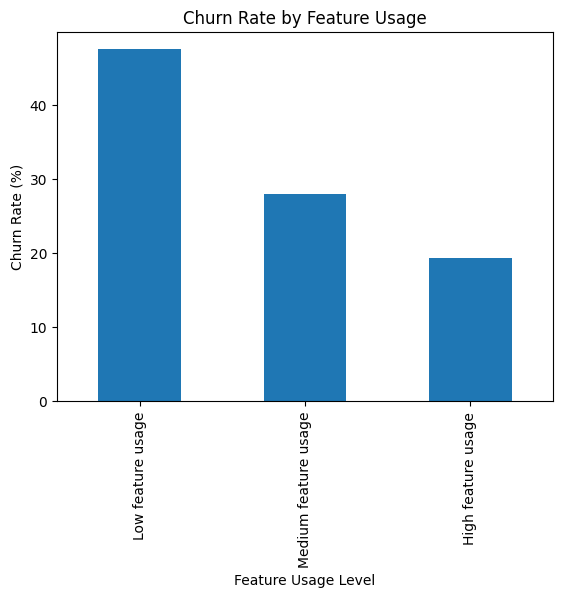

In [12]:
churn_by_feature_usage.plot(kind="bar")
plt.title("Churn Rate by Feature Usage")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Feature Usage Level")
plt.show()


### Churn by Feature Usage

Customers with low feature usage have the highest churn rate at around 47.5%, compared to 27.9% for medium feature usage and 19.4% for high feature usage.

This suggests that customers who discover and use more parts of the product are more likely to stay. Low feature usage may indicate that customers have not fully understood the product’s value or have not reached their “aha moment.”

From a product perspective, the business should improve onboarding, highlight underused features, and create in-app prompts that encourage customers to try more features early in their lifecycle.

### Step 7: Analyse training completion
Question:
- Does completing onboarding/training reduce churn?

- 0 = did not complete training
- 1 = completed training


In [13]:
churn_by_training = df.groupby("training_completed")["churned"].mean() * 100
churn_by_training


training_completed
0    35.618280
1    23.407643
Name: churned, dtype: float64

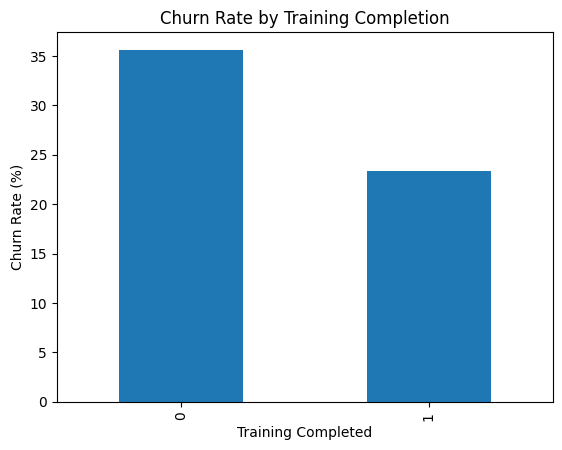

In [14]:
churn_by_training.plot(kind="bar")
plt.title("Churn Rate by Training Completion")  
plt.ylabel("Churn Rate (%)")
plt.xlabel("Training Completed")
plt.show()

### Churn by Training Completion

Customers who did not complete training have a churn rate of around 35.6%, compared to 23.4% for customers who completed training.

This suggests that onboarding plays an important role in retention. Customers who complete training are more likely to understand the product, discover its value, and continue using it.

From a product perspective, the business should encourage users to complete onboarding early, send reminders to customers who abandon training, and track training completion as a key activation metric.

## Step 8: Analyse billing issues

Question:
- Do billing issues increase churn?

Interpretation:
- 0 = no billing issue
- 1 = had billing issue

In [15]:
churn_by_billings = df.groupby("billing_issues")["churned"].mean() * 100
churn_by_billings


billing_issues
0    26.043504
1    38.795987
Name: churned, dtype: float64

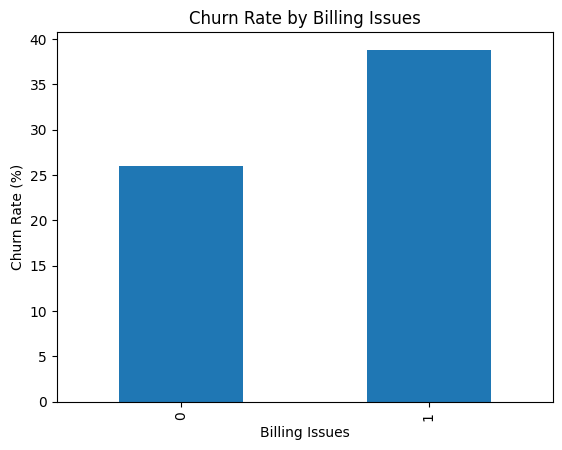

In [16]:

churn_by_billings.plot(kind="bar")
plt.title("Churn Rate by Billing Issues")   
plt.ylabel("Churn Rate (%)")
plt.xlabel("Billing Issues")
plt.show()

### Churn by Billing Issues

Customers with billing issues have a churn rate of around 38.8%, compared to 26.0% for customers without billing issues.

This suggests that billing problems may increase the likelihood of churn. Even if customers find value in the product, payment friction or unresolved billing issues can create frustration and push them to cancel.

From a product and customer success perspective, billing issues should be treated as an early warning signal. The business should quickly identify affected customers, resolve payment problems, and follow up before they churn.

### Step 9: Analyse support tickets

Question:
- Do customers with more support tickets churn more?

In [17]:
df["support_ticket_level"] = pd.cut(
    df["support_tickets"],
    bins=[-1, 0, 2, 5],
    labels=["No tickets", "Some tickets", "Many tickets"]
)

#Then:
churn_by_support = df.groupby("support_ticket_level")["churned"].mean() * 100
churn_by_support

support_ticket_level
No tickets      21.935484
Some tickets    25.510204
Many tickets    31.474104
Name: churned, dtype: float64

### Churn by Support Ticket Level

A support ticket is a customer issue, complaint, or request sent to the support team. In this dataset, support tickets represent how often a customer needed help with the product.

Customers with many support tickets have the highest churn rate at around 31.5%, compared to 25.5% for customers with some tickets and 21.9% for customers with no tickets.

This suggests that customers who experience more issues or need more support may be more likely to churn. From a product perspective, frequent support tickets can be an early warning signal of frustration, confusion, or unresolved product problems.

The business should monitor customers with repeated support tickets and prioritise follow-up, product education, or bug resolution before they cancel.

## Investigating Pro Plan Churn

### Deeper dive: Why are Pro Users Churning????

Although Free users have the highest churn rate overall, Pro users have a slightly higher churn rate than Starter users. Since Pro users are paying more, this is worth investigating.

The goal of this section is to understand whether Pro churn may be linked to lower activity, lower feature usage, incomplete training, billing issues, or support tickets.

#### Step 1: Compare only Starter and Pro users

In [18]:
#filter to just Starter and Pro plans:
starter_pro = df[df["plan_type"].isin(["Starter", "Pro"])]

starter_pro.groupby("plan_type")["churned"].mean() * 100

plan_type
Pro        30.322581
Starter    26.067073
Name: churned, dtype: float64

Step 2: Compare activity level by plan

Since low activity had high churn, check whether Pro users are less active than Starter users.

Do Pro users have a higher percentage of low-activity customers?

In [19]:


pd.crosstab(
    starter_pro["plan_type"],
    starter_pro["activity_level"],
    normalize="index"
) * 100

activity_level,Low activity,Medium activity,High activity
plan_type,,,
Pro,16.935484,32.096774,50.967742
Starter,15.853659,30.640244,53.506098


### Pro vs Starter: Activity Level

The activity comparison shows that Pro users have a slightly higher share of low-activity customers than Starter users. Pro users also have a slightly lower share of high-activity customers.

However, the difference is not large enough to fully explain why Pro users have a higher churn rate than Starter users. This suggests that Pro churn may be influenced by other factors such as feature usage, support tickets, billing issues, or onboarding completion.

The next step is to compare Pro and Starter users by feature usage and support behaviour.

#### Step 3: Compare feature usage by plan

Since low feature usage also had high churn, check feature usage between Starter and Pro users:


Are Pro users using fewer features than expected?

In [20]:


pd.crosstab(
    starter_pro["plan_type"],
    starter_pro["feature_usage"],
    normalize="index"
) * 100

feature_usage,Low feature usage,Medium feature usage,High feature usage
plan_type,,,
Pro,20.645161,37.903226,41.451613
Starter,15.701220,43.902439,40.396341


### Pro vs Starter: Feature Usage

The feature usage comparison shows that Pro users have a higher share of low-feature-usage customers than Starter users. About 20.7% of Pro users fall into the low feature usage group, compared to 15.7% of Starter users.

This is important because the earlier analysis showed that low feature usage is strongly linked to churn. This suggests that some Pro users may be paying for a higher plan but not using enough product features to justify the cost.

From a product perspective, this could indicate a value gap for Pro users. The business may need to improve Pro onboarding, highlight premium features more clearly, and encourage Pro users to adopt the features that make the higher plan worthwhile.

#### Step 4: Compare training completion by plan


- 0 = did not complete training
- 1 = completed training

Are more Pro users failing to complete training?

In [21]:
pd.crosstab(
    starter_pro["plan_type"],
    starter_pro["training_completed"],
    normalize="index"
) * 100

training_completed,0,1
plan_type,,
Pro,35.645161,64.354839
Starter,37.652439,62.347561


Pro users actually completed training slightly more than Starter users, so onboarding completion is probably not the main reason Pro users are churning more.

#### Step 5: Compare support tickets by plan

Do Pro users raise more support tickets?

In [22]:
starter_pro.groupby("plan_type")["support_tickets"].mean()


plan_type
Pro        2.483871
Starter    2.559451
Name: support_tickets, dtype: float64

Starter users have slightly more support tickets, so support ticket volume is also not the main reason Pro churn is higher.

#### Step 6: Compare billing issues by plan

Do Pro users have more billing issues?

In [23]:
starter_pro.groupby("plan_type")["billing_issues"].mean() * 100

plan_type
Pro        12.741935
Starter    15.548780
Name: billing_issues, dtype: float64

Starter users have more billing issues than Pro users, so billing issues are not the reason Pro users churn more.

#### Step 7: Look specifically at churned Pro users

This is useful.

This helps understand the profile of Pro users who churned.


What do churned Pro users have in common?

In [24]:
pro_users = df[df["plan_type"] == "Pro"]
churned_pro_users = pro_users[pro_users["churned"] == 1]

churned_pro_users[
    [
        "days_active_last_30",
        "last_login_days_ago",
        "features_used",
        "support_tickets",
        "billing_issues",
        "training_completed"
    ]
].describe()

,days_active_last_30,last_login_days_ago,features_used,support_tickets,billing_issues,training_completed
count,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000
mean,12.404255,17.388298,4.686170,2.792553,0.196809,0.531915
std,8.810930,8.522588,2.981659,1.649679,0.398648,0.500313
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,4.000000,11.000000,2.000000,1.000000,0.000000,0.000000
50%,12.000000,18.000000,4.000000,3.000000,0.000000,1.000000
75%,20.250000,25.000000,7.000000,4.000000,0.000000,1.000000
max,30.000000,30.000000,10.000000,5.000000,1.000000,1.000000


The strongest clue is still feature usage

Earlier, I found using the data:

- Pro low feature usage: 20.65%
- Starter low feature usage: 15.70%

This is the most useful explanation so far.

It suggests that some Pro users may be paying for a higher plan but not using enough features to justify the cost.

### Why Might Pro Users Be Churning?

The deeper analysis shows that Pro users have a slightly higher churn rate than Starter users, but this does not appear to be mainly caused by training completion, support tickets, or billing issues.

-- Pro users actually have a slightly higher training completion rate than Starter users. They also have slightly fewer support tickets and fewer billing issues on average. This means the higher Pro churn rate is unlikely to be explained by onboarding failure, support friction, or billing problems alone.

-- The strongest clue is feature usage. Pro users have a higher share of low-feature-usage customers than Starter users. This is important because the earlier analysis showed that low feature usage is strongly linked to churn.

-- This suggests that some Pro customers may be paying for a higher plan but not using enough of the product to feel the value of that plan. In other words, the issue may not be that Pro users cannot use the product, but that some of them are not adopting enough Pro-level features to justify the subscription cost.

-- From a product perspective, the business should monitor Pro users who have low feature usage, low recent activity, or long periods since their last login. These customers may need targeted feature education, upgrade value reminders, or customer success outreach to help them get more value from the Pro plan.

## Final Insights

The exploratory analysis shows that customer churn is strongly linked to `product engagement`, `feature adoption`, `onboarding`, `billing experience`, and `support activity`.

- The overall churn rate in the dataset is around `28%`, which gives a realistic baseline for the project. Low-activity customers had the highest churn rate, suggesting that regular product usage is an important retention signal. Customers with low feature usage also had much higher churn, which suggests that customers are more likely to stay when they discover and use more of the product.

- Training completion also appears to matter. Customers who completed training had a lower churn rate than those who did not, showing that onboarding can help customers understand the product and reach value faster.

- Billing issues and support tickets were also linked to higher churn. Customers with billing issues churned more than customers without billing problems, and customers with many support tickets churned more than those with no tickets. This suggests that payment friction and unresolved product issues can increase churn risk.

- A deeper dive into Pro users showed that their slightly higher churn rate compared to Starter users is most likely linked to lower feature adoption rather than billing issues, support tickets, or training completion. This suggests that some Pro users may not be using enough Pro-level features to justify the higher subscription cost.

Based on these insights, the final RetentionIQ dashboard should focus on key churn indicators such as activity level, feature usage, onboarding completion, billing issues, support ticket volume, and plan type.